# Async Lab: The Green AI Trade-Off
# 异步实验：绿色 AI 权衡

**Objective:** Compare accuracy vs. CO₂ emissions across 4 Deep MLP training configurations (data size × epochs), tracked with CodeCarbon.

**Dataset:** Fashion-MNIST  
**Model:** Deep MLP — `Flatten` + ≥5 `Dense` hidden layers + softmax output

In [1]:
# Colab / cloud: install missing packages
%pip install -q codecarbon
# Uncomment if TensorFlow is not available:
# %pip install -q tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.9/388.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 28.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from codecarbon import EmissionsTracker

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 1. Load & Preprocess Fashion-MNIST | 加载与预处理

- Normalize pixels to `[0, 1]`
- Add channel dim → shape `(28, 28, 1)`
- **Test set stays fixed** for all 4 experiments

In [3]:
def load_and_preprocess_data():
    """Returns X_train_full, y_train_full, X_test, y_test, input_shape, num_classes."""
    (X_train_full, y_train_full), (X_test, y_test) = (
        tf.keras.datasets.fashion_mnist.load_data()
    )
    X_train_full = X_train_full.astype("float32") / 255.0
    X_test = X_test.astype("float32") / 255.0
    X_train_full = np.expand_dims(X_train_full, axis=-1)
    X_test = np.expand_dims(X_test, axis=-1)
    input_shape = (28, 28, 1)
    num_classes = 10
    return X_train_full, y_train_full, X_test, y_test, input_shape, num_classes


X_train_full, y_train_full, X_test, y_test, input_shape, num_classes = (
    load_and_preprocess_data()
)

print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("input_shape:", input_shape, "| num_classes:", num_classes)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train_full: (60000, 28, 28, 1)
y_train_full: (60000,)
X_test: (10000, 28, 28, 1)
y_test: (10000,)
input_shape: (28, 28, 1) | num_classes: 10


## 2. Helpers | 辅助函数

- `get_train_data` — slice training data by fraction
- `build_mlp` — Flatten + 5 Dense hidden layers + softmax
- `run_experiment` — build from scratch, track CO₂, evaluate

In [4]:
EXPERIMENTS = [
    {"name": "A", "data_fraction": 0.5, "epochs": 50},
    {"name": "B", "data_fraction": 0.5, "epochs": 100},
    {"name": "C", "data_fraction": 1.0, "epochs": 50},
    {"name": "D", "data_fraction": 1.0, "epochs": 100},
]


def get_train_data(X_full, y_full, fraction):
    """Slice training data by fraction."""
    n = int(len(X_full) * fraction)
    return X_full[:n], y_full[:n]


def build_mlp(input_shape, num_classes):
    """Build a deep MLP with Flatten + ≥5 Dense hidden layers."""
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation="relu"),  # hidden 1
        tf.keras.layers.Dense(256, activation="relu"),  # hidden 2
        tf.keras.layers.Dense(128, activation="relu"),  # hidden 3
        tf.keras.layers.Dense(64, activation="relu"),   # hidden 4
        tf.keras.layers.Dense(32, activation="relu"),   # hidden 5
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])
    return model


def run_experiment(
    name,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs,
    input_shape,
    num_classes,
    data_fraction,
):
    """Build fresh model, train under CodeCarbon, evaluate on fixed test set."""
    model = build_mlp(input_shape, num_classes)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    tracker = EmissionsTracker(
        project_name="green-ai-tradeoff",
        output_file="emissions.csv",
        log_level="error",
    )
    tracker.start()
    model.fit(X_train, y_train, epochs=epochs, batch_size=128, verbose=1)
    emissions_g = tracker.stop()  # grams CO₂

    _, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    return {
        "experiment": name,
        "data_fraction": data_fraction,
        "epochs": epochs,
        "train_samples": len(X_train),
        "test_accuracy": float(test_accuracy),
        "test_accuracy_pct": round(float(test_accuracy) * 100, 2),
        "emissions_g": round(float(emissions_g), 4),
    }


# Sanity-check architecture
_demo = build_mlp(input_shape, num_classes)
_demo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 576,810 (2.20 MB)

 Trainable params: 576,810 (2.20 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Experiment Matrix | 实验矩阵

| Experiment | Training Data | Epochs |
|------------|---------------|--------|
| **A** | 50% | 50 |
| **B** | 50% | 100 |
| **C** | 100% | 50 |
| **D** | 100% | 100 |

Each run builds and trains a **new model from scratch**. CodeCarbon appends to `emissions.csv`.

In [5]:
results = []

for cfg in EXPERIMENTS:
    print("\n" + "=" * 60)
    print(f"Experiment {cfg['name']}: "
          f"data_fraction={cfg['data_fraction']}, epochs={cfg['epochs']}")
    print("=" * 60)

    X_train, y_train = get_train_data(
        X_train_full, y_train_full, cfg["data_fraction"]
    )
    result = run_experiment(
        name=cfg["name"],
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        epochs=cfg["epochs"],
        input_shape=input_shape,
        num_classes=num_classes,
        data_fraction=cfg["data_fraction"],
    )
    results.append(result)
    print(f"→ accuracy={result['test_accuracy_pct']}% | "
          f"CO₂={result['emissions_g']} g")

results_df = pd.DataFrame(results)
print("\n=== Summary ===")
display(results_df)


Experiment A: data_fraction=0.5, epochs=50


[codecarbon WARNING @ 14:31:59] Multiple instances of codecarbon are allowed to run at the same time.


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7683 - loss: 0.6558
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8469 - loss: 0.4198
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8629 - loss: 0.3719
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8770 - loss: 0.3318
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8839 - loss: 0.3129
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8881 - loss: 0.2954
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8937 - loss: 0.2802
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8966 - loss: 0.2728
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9023 - loss: 0.2561
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9069 - loss: 0.2429
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9089 - loss: 0.2386
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 

,experiment,data_fraction,epochs,train_samples,test_accuracy,test_accuracy_pct,emissions_g
0,A,0.5,50,30000,0.8857,88.57,0.0003
1,B,0.5,100,30000,0.8833,88.33,0.0006
2,C,1.0,50,60000,0.8974,89.74,0.0007
3,D,1.0,100,60000,0.8997,89.97,0.0013


## 4. Visualization | 可视化

Twin-axis bar chart: **Test Accuracy (%)** vs **CO₂ Emissions (g)**. Saves `tradeoff_plot.png`.

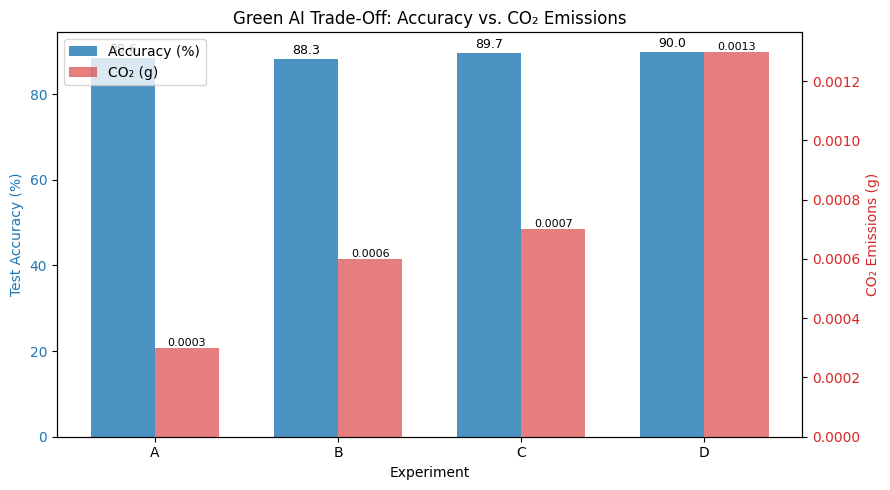

Saved plot → tradeoff_plot.png


In [6]:
def plot_tradeoff(results_df, save_path="tradeoff_plot.png"):
    """Plot accuracy (%) and CO₂ (g) on twin y-axes."""
    labels = results_df["experiment"].tolist()
    acc = results_df["test_accuracy_pct"].tolist()
    co2 = results_df["emissions_g"].tolist()

    x = np.arange(len(labels))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(9, 5))

    color1 = "tab:blue"
    bars1 = ax1.bar(x - width / 2, acc, width, color=color1, alpha=0.8, label="Accuracy (%)")
    ax1.set_xlabel("Experiment")
    ax1.set_ylabel("Test Accuracy (%)", color=color1)
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.tick_params(axis="y", labelcolor=color1)

    ax2 = ax1.twinx()
    color2 = "tab:red"
    bars2 = ax2.bar(x + width / 2, co2, width, color=color2, alpha=0.6, label="CO₂ (g)")
    ax2.set_ylabel("CO₂ Emissions (g)", color=color2)
    ax2.tick_params(axis="y", labelcolor=color2)

    for bar, val in zip(bars1, acc):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    for bar, val in zip(bars2, co2):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.4f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.title("Green AI Trade-Off: Accuracy vs. CO₂ Emissions")
    fig.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved plot → {save_path}")


plot_tradeoff(results_df)

## 5. Upload


In [9]:
!pip install PyGithub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.6 MB/s eta 0:00:00


In [11]:
from github import Github, GithubException, Auth
from datetime import datetime
from google.colab import userdata

# GitHub Credentials and Targeting
STUDENT_TOKEN = userdata.get('STUDENT_TOKEN')
REPO_NAME = "nikk909/mds7-YueMa"
TARGET_FOLDER = "week-10-12-async-lab"

# Authenticate with GitHub (Updated Auth Method)
auth = Auth.Token(STUDENT_TOKEN)
g = Github(auth=auth)
repo = g.get_repo(REPO_NAME)
print(f"Authenticated to repository: {repo.full_name}")

Authenticated to repository: nikk909/mds7-YueMa


In [ ]:
from datetime import datetime
from google.colab import _message
from github import GithubException
import json
import os

# --- Step 6: Save notebook + Upload deliverables + Update Audit Trail ---

NOTEBOOK_NAME = "The_Green_AI_Trade-Off.ipynb"

# 1) Save current Colab notebook to /content (so it can be uploaded)
notebook = _message.blocking_request("get_ipynb", timeout_sec=10)["ipynb"]
with open(NOTEBOOK_NAME, "w", encoding="utf-8") as f:
    f.write(json.dumps(notebook, indent=1))
print("Notebook saved locally:", os.path.exists(NOTEBOOK_NAME))

# 2) Upload deliverables to week-10-12-async-lab/
files_to_upload = [
    NOTEBOOK_NAME,
    "README.md",
    "tradeoff_plot.png",
    "emissions.csv",
]

print(f"\nUploading to {TARGET_FOLDER}/ ...")

for local_path in files_to_upload:
    if not os.path.exists(local_path):
        print(f"⚠️ Skip (not found): {local_path}")
        continue

    with open(local_path, "rb") as f:
        file_content = f.read()

    git_path = f"{TARGET_FOLDER}/{local_path}"

    try:
        git_obj = repo.get_contents(git_path, ref="main")
        repo.update_file(
            path=git_path,
            message=f"Update {local_path} (Green AI Trade-Off)",
            content=file_content,
            sha=git_obj.sha,
            branch="main",
        )
        print(f"✅ Updated: {git_path}")
    except GithubException as e:
        if e.status == 404:
            repo.create_file(
                path=git_path,
                message=f"Add {local_path} (Green AI Trade-Off)",
                content=file_content,
                branch="main",
            )
            print(f"✅ Created: {git_path}")
        else:
            raise

# 3) Update AUDIT_TRAIL.md
print("\nUpdating AUDIT_TRAIL.md...")

try:
    audit_file = repo.get_contents("AUDIT_TRAIL.md", ref="main")
    current_content = audit_file.decoded_content.decode("utf-8")
    timestamp_str = datetime.now().strftime("%Y-%m-%d %H:%M")

    new_entry = f"""
## Week 10-12: Green AI Trade-Off (Accuracy vs. CO₂)
* **Date:** {timestamp_str}
* **Milestone:** Completed Deep MLP carbon-vs-data experiments with CodeCarbon tracking.
* **Notes:** Trained 4 MLP configs (A–D) on Fashion-MNIST; tracked CO₂ via EmissionsTracker. Winning config = Experiment C (100% data, 50 epochs; Acc 89.74%, CO₂ 0.0007 g). Synced notebook, emissions.csv, tradeoff_plot.png, and README conclusion to GitHub (`week-10-12-async-lab`).
"""

    updated_content = current_content + new_entry

    repo.update_file(
        path="AUDIT_TRAIL.md",
        message="Audit: Green AI Trade-Off experiments & Winning Config C",
        content=updated_content,
        sha=audit_file.sha,
        branch="main",
    )
    print("✅ AUDIT_TRAIL.md updated successfully with Green AI Trade-Off milestones.")

except Exception as e:
    print(f"❌ Error updating audit trail: {e}")